# <center>**Vignetting Effect Benchmark**<center>

In [1]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
from numpy.typing import NDArray
import matplotlib as mpl
import matplotlib.pyplot as plt

from bloodmoon.types import CoordEquatorial
from bloodmoon.io import simulation_files
from bloodmoon.coords import equatorial2pos
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode
from bloodmoon.optim import model_sky
from bloodmoon.images import argmax
import darksun as ds
from darksun.data import CatalogueLoader, DataLoader
from darksun.benchmarking import source_catalogue_data

from IROSrec.handle import config_dirpaths
import imgmaker as mgm

ds.show.set_figures_darkbkg()

In [2]:
def get_source_coords(
    sourceID: str,
    catalogue: CatalogueLoader,
) -> CoordEquatorial:
    """Retrieves the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

In [3]:
MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 10, 1

SKYFIELD: str = "CameraGeometry"

DATA_FITS_thin: str = "baseline_thinmask_infdet_1ks_2-50keV"
DATA_FITS: str = "baseline_2-50keV_1ks"
RUN_ID: str = 'baseline_wcxb'

ID_CAMERA_A: str = "cam1a"
DATASET: str = "detected"

PSFY: bool = mgm.config_psfy_flag(DATASET)

E_min, E_max = 2.0, 4.0           # [keV]
exclude_coords: CoordEquatorial | list[CoordEquatorial] | None = [
        CoordEquatorial(318.950871147977, -51.1920260999562),   # s0
        CoordEquatorial(296.376333558386, 5.25424886863538),    # s1
        CoordEquatorial(236.423666441614, 5.25424886863538),    # s2
        CoordEquatorial(213.849128852023, -51.1920260999562),   # s3
        CoordEquatorial(286.170341181402, -42.2037736309785),   # s4
        CoordEquatorial(281.331753525598, -13.4867719837475),   # s5
        # CoordEquatorial(251.468246474402, -13.4867719837475),   # s6
        CoordEquatorial(246.629658818598, -42.2037736309785),   # s7
        CoordEquatorial(266.4, -28.94),                         # s8
    ]
# exclude_coords: CoordEquatorial | list[CoordEquatorial] | None = None

In [4]:
MASK_PATH, SIMUL_DATA_PATH_thin, SAVE_PATH_thin = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS_thin,
    runID=RUN_ID,
)
_, SIMUL_DATA_PATH, SAVE_PATH = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    runID=RUN_ID,
)
OUT_RESULTS_PATH = '/home/edoardo/Desktop'
# OUT_RESULTS_PATH = '/mnt/d/PhD_AASS/Coding/Images_fits'

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

sdlA_thin = ds.get_data(
    SIMUL_DATA_PATH_thin + f'{ID_CAMERA_A}/{DATA_FITS_thin}_{ID_CAMERA_A}_{DATASET}.fits',
    E_min=E_min, E_max=E_max, coords=exclude_coords,
)
sdlA = ds.get_data(
    SIMUL_DATA_PATH + f'{ID_CAMERA_A}/{DATA_FITS}_{ID_CAMERA_A}_{DATASET}.fits',
    E_min=E_min, E_max=E_max, coords=exclude_coords,
)
catalogue = ds.get_catalogue(SIMUL_DATA_PATH + f'{ID_CAMERA_A}/{DATA_FITS}_{ID_CAMERA_A}_sources.fits')

logA_thin, _ = ds.load_database(f"{SAVE_PATH_thin}/OUT_{RUN_ID}_srcDB.fits")
logA, _ = ds.load_database(f"{SAVE_PATH}/OUT_{RUN_ID}_srcDB.fits")
cu_map = mgm.get_srcmap_for_unit(logA_thin.log['ID'], logA.log['ID'])

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [5]:
d_thin: NDArray = count(wfm, sdlA_thin.DLdata)[0]
skymap_thin: NDArray = decode(wfm, d_thin)

detector: NDArray = count(wfm, sdlA.DLdata)[0]
skymap: NDArray = decode(wfm, detector)

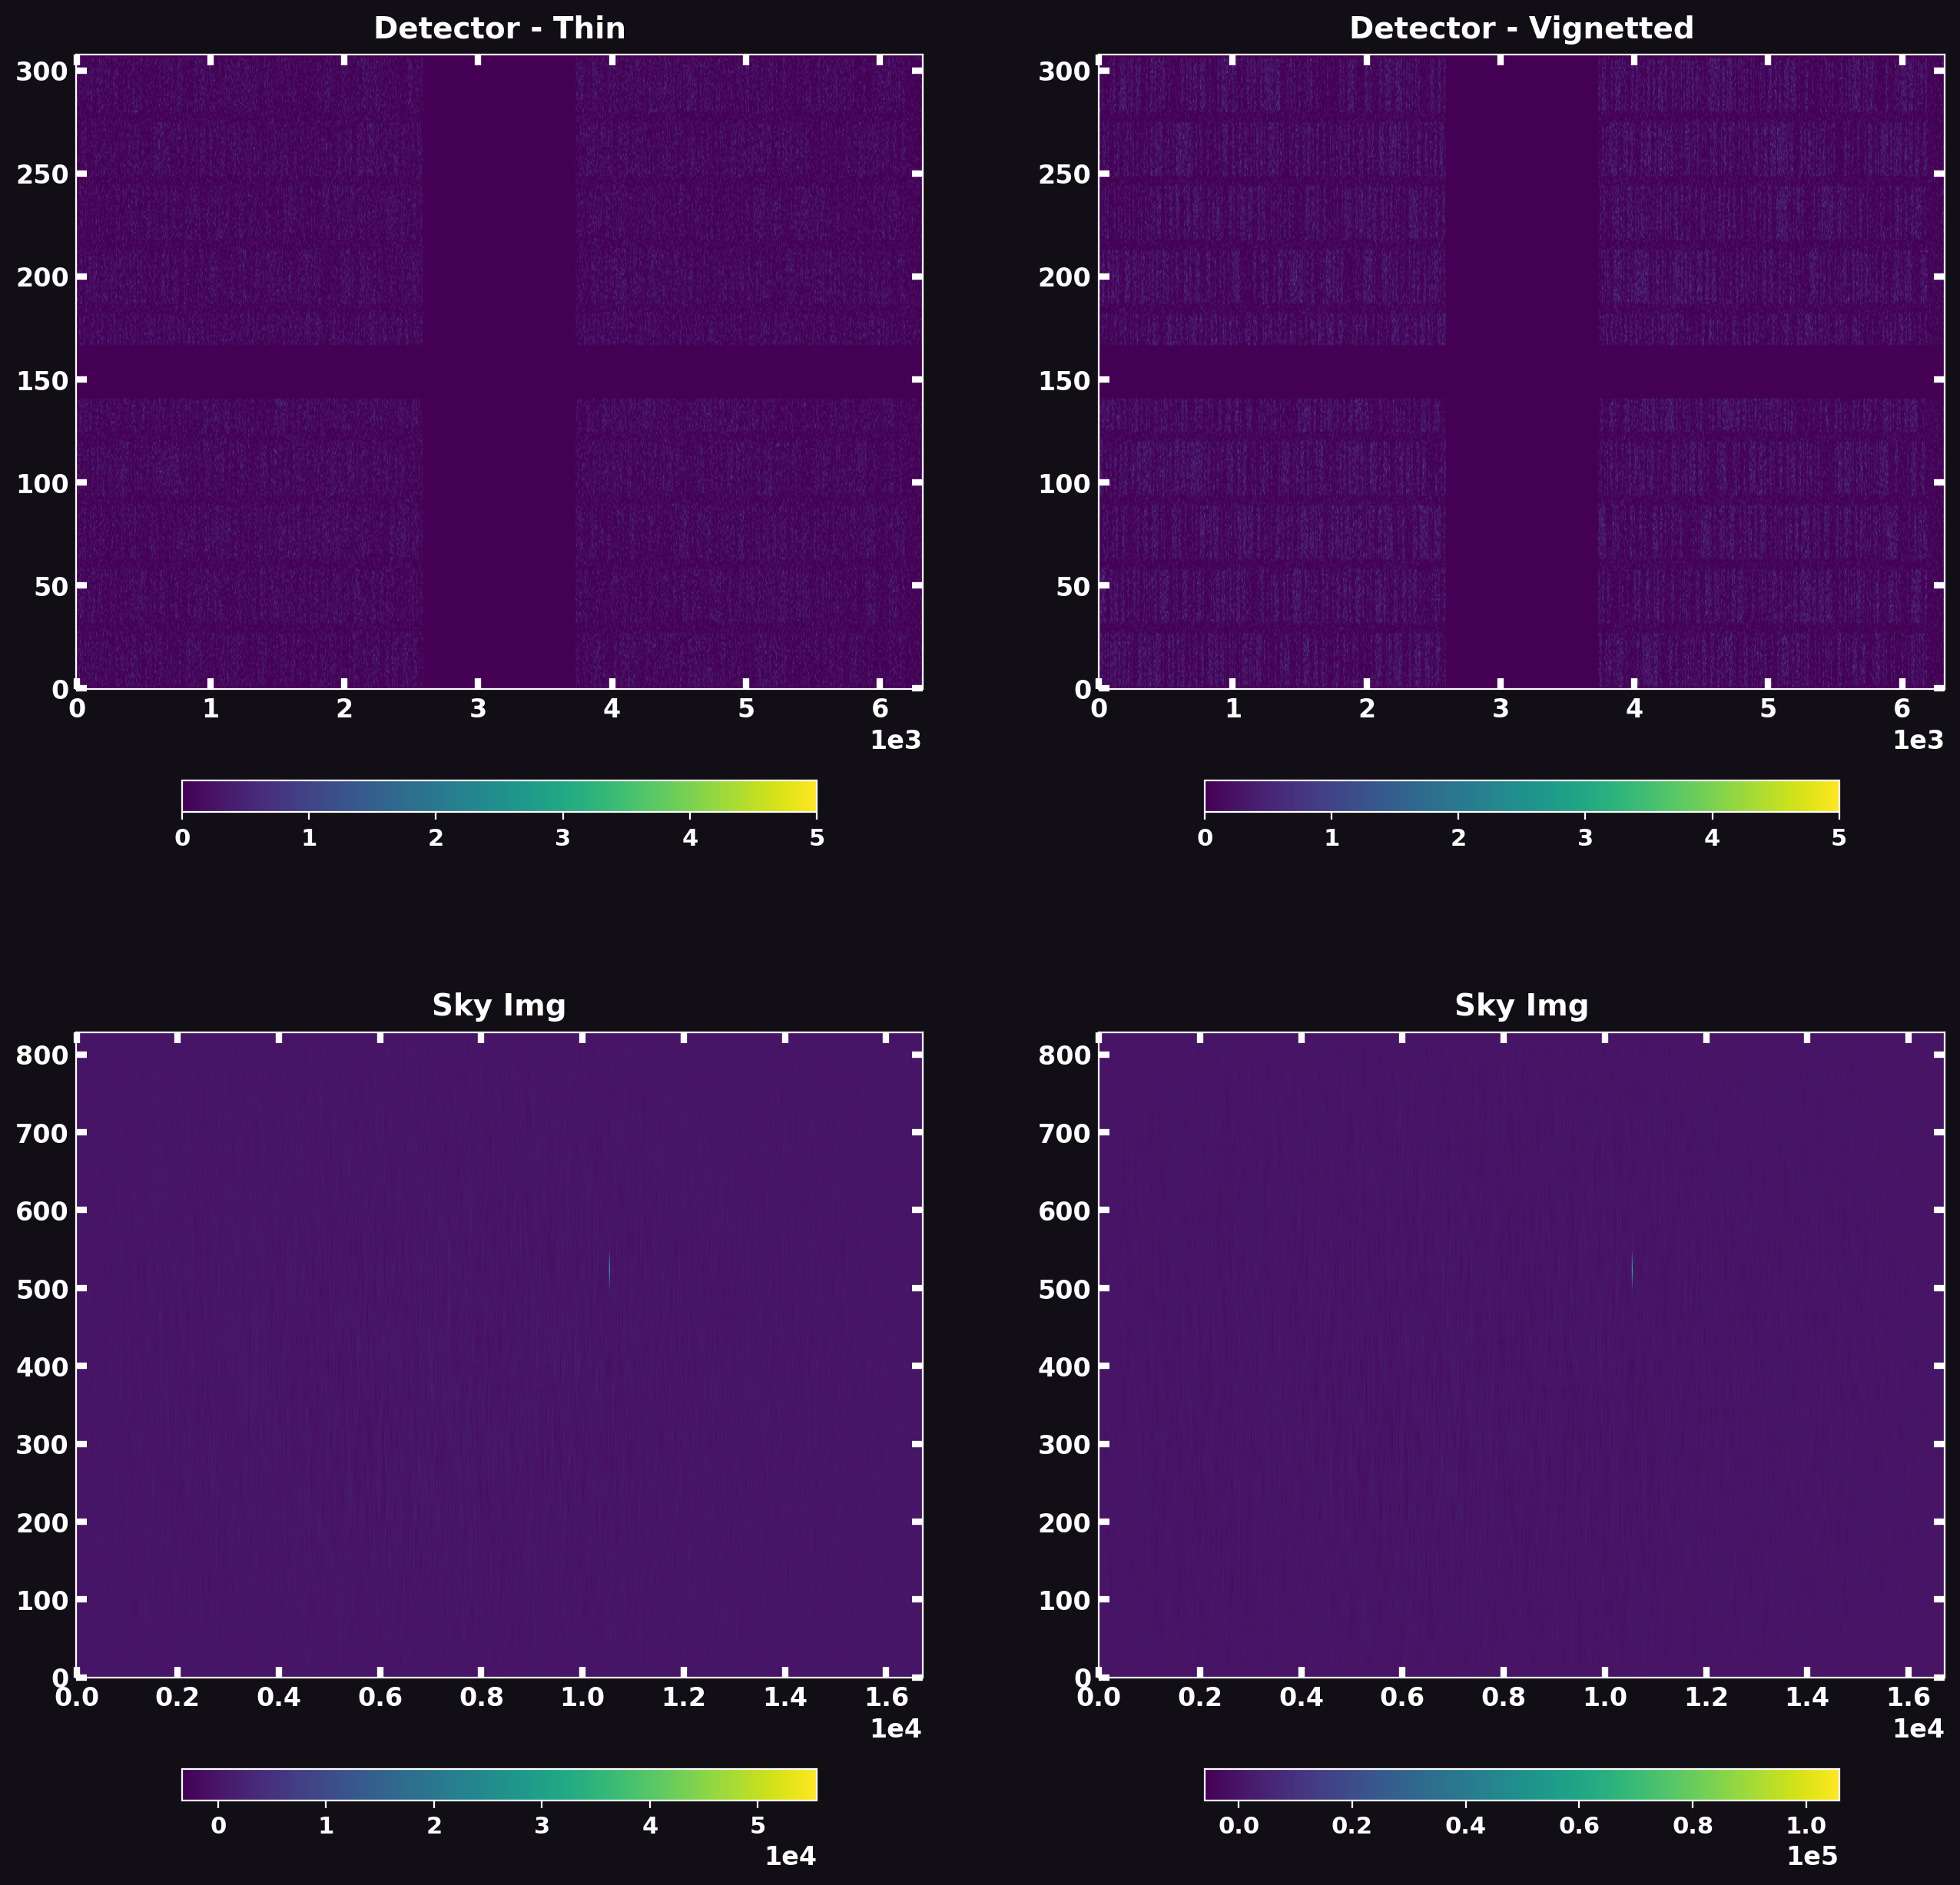

In [6]:
ASPECT = 0.75 * wfm.shape_detector[1] / wfm.shape_detector[0]
ds.image_plot(
    dmaps=(
        ds.map4image(d_thin, title='Detector - Thin', cbarloc='bottom', img_kwargs={'aspect': ASPECT}),
        ds.map4image(detector, title='Detector - Vignetted', cbarloc='bottom', img_kwargs={'aspect': ASPECT}),
        ds.map4image(skymap_thin, title='Sky Img', cbarloc='bottom', img_kwargs={'aspect': ASPECT}),
        ds.map4image(skymap, title='Sky Img', cbarloc='bottom', img_kwargs={'aspect': ASPECT}),
    ),
    ncols=2,
    nrows=2,
)

In [7]:
SRC_ID = 's6'

IDX: int = int(np.argwhere(cu_map.common == SRC_ID)[0, 0])
SRC_DATA = {
    'sx': np.array(logA.log['shift_x'])[cu_map.idx_b][IDX],
    'sy': np.array(logA.log['shift_x'])[cu_map.idx_b][IDX],
    'cts': np.array(logA.log['fluence'])[cu_map.idx_b][IDX],
    'pos': equatorial2pos(sdlA, wfm, *get_source_coords(SRC_ID, catalogue)),
    'crp': (40 * wfm.upscale_f.y, 2 * wfm.upscale_f.x + 1),
    'colors': ('Orange', 'DeepSkyblue'),
}

template_thin = model_sky(wfm, SRC_DATA['sx'], SRC_DATA['sy'], SRC_DATA['cts'], vignetting=False, psfy=False)
template = model_sky(wfm, SRC_DATA['sx'], SRC_DATA['sy'], SRC_DATA['cts'], psfy=False)

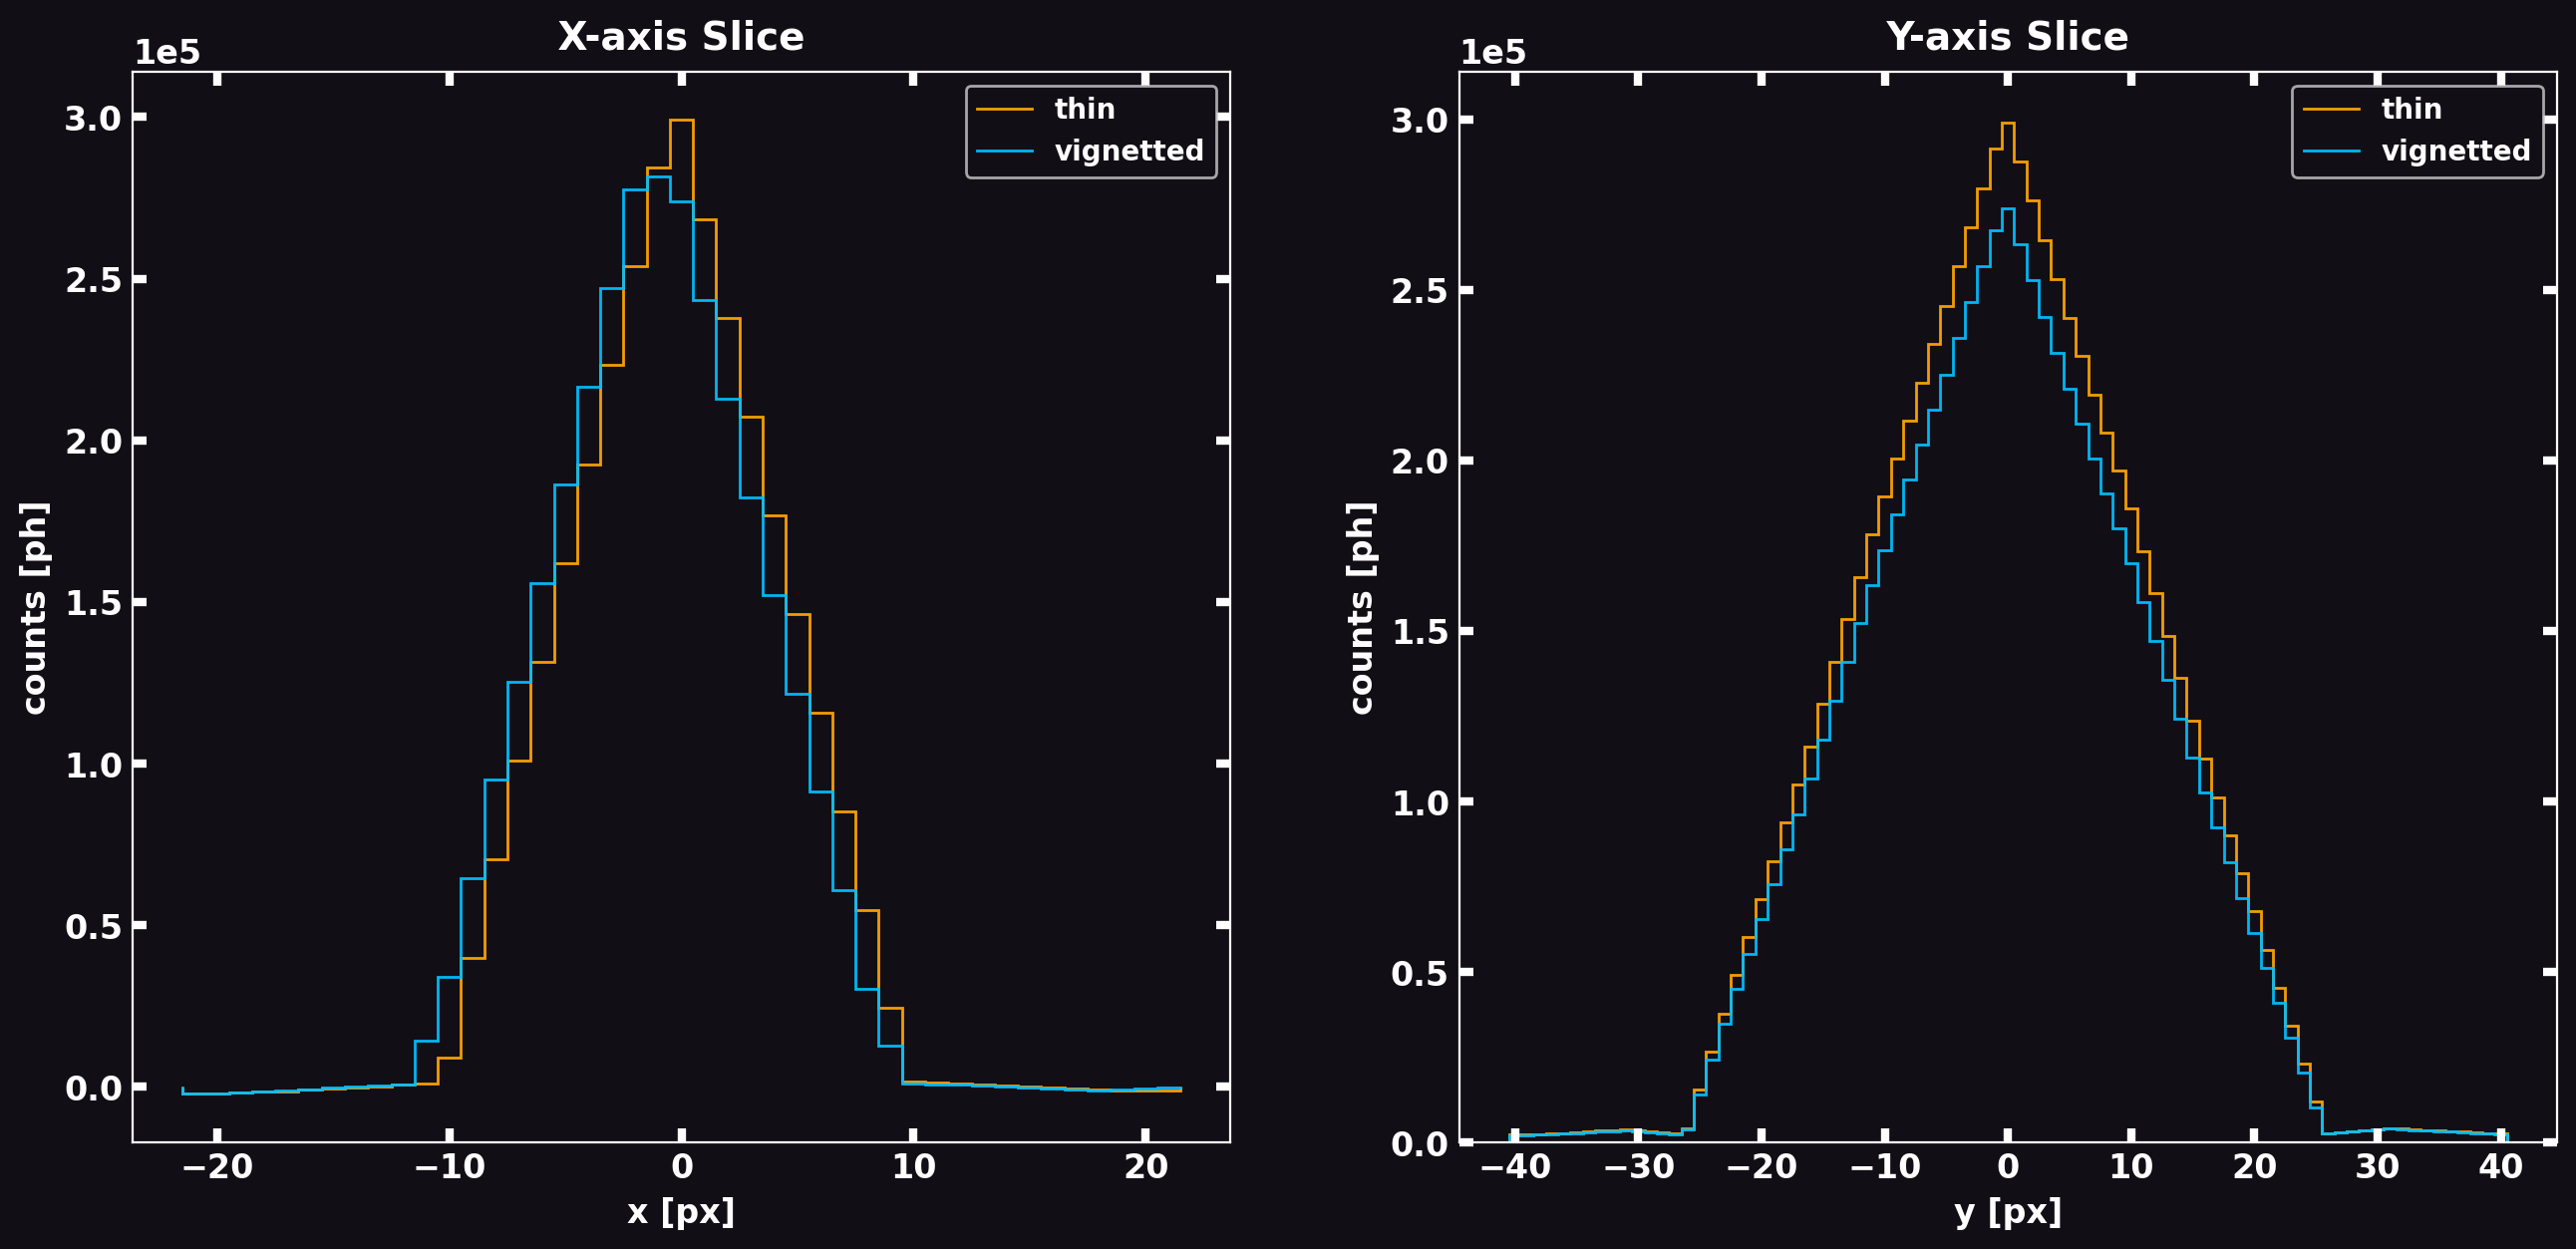

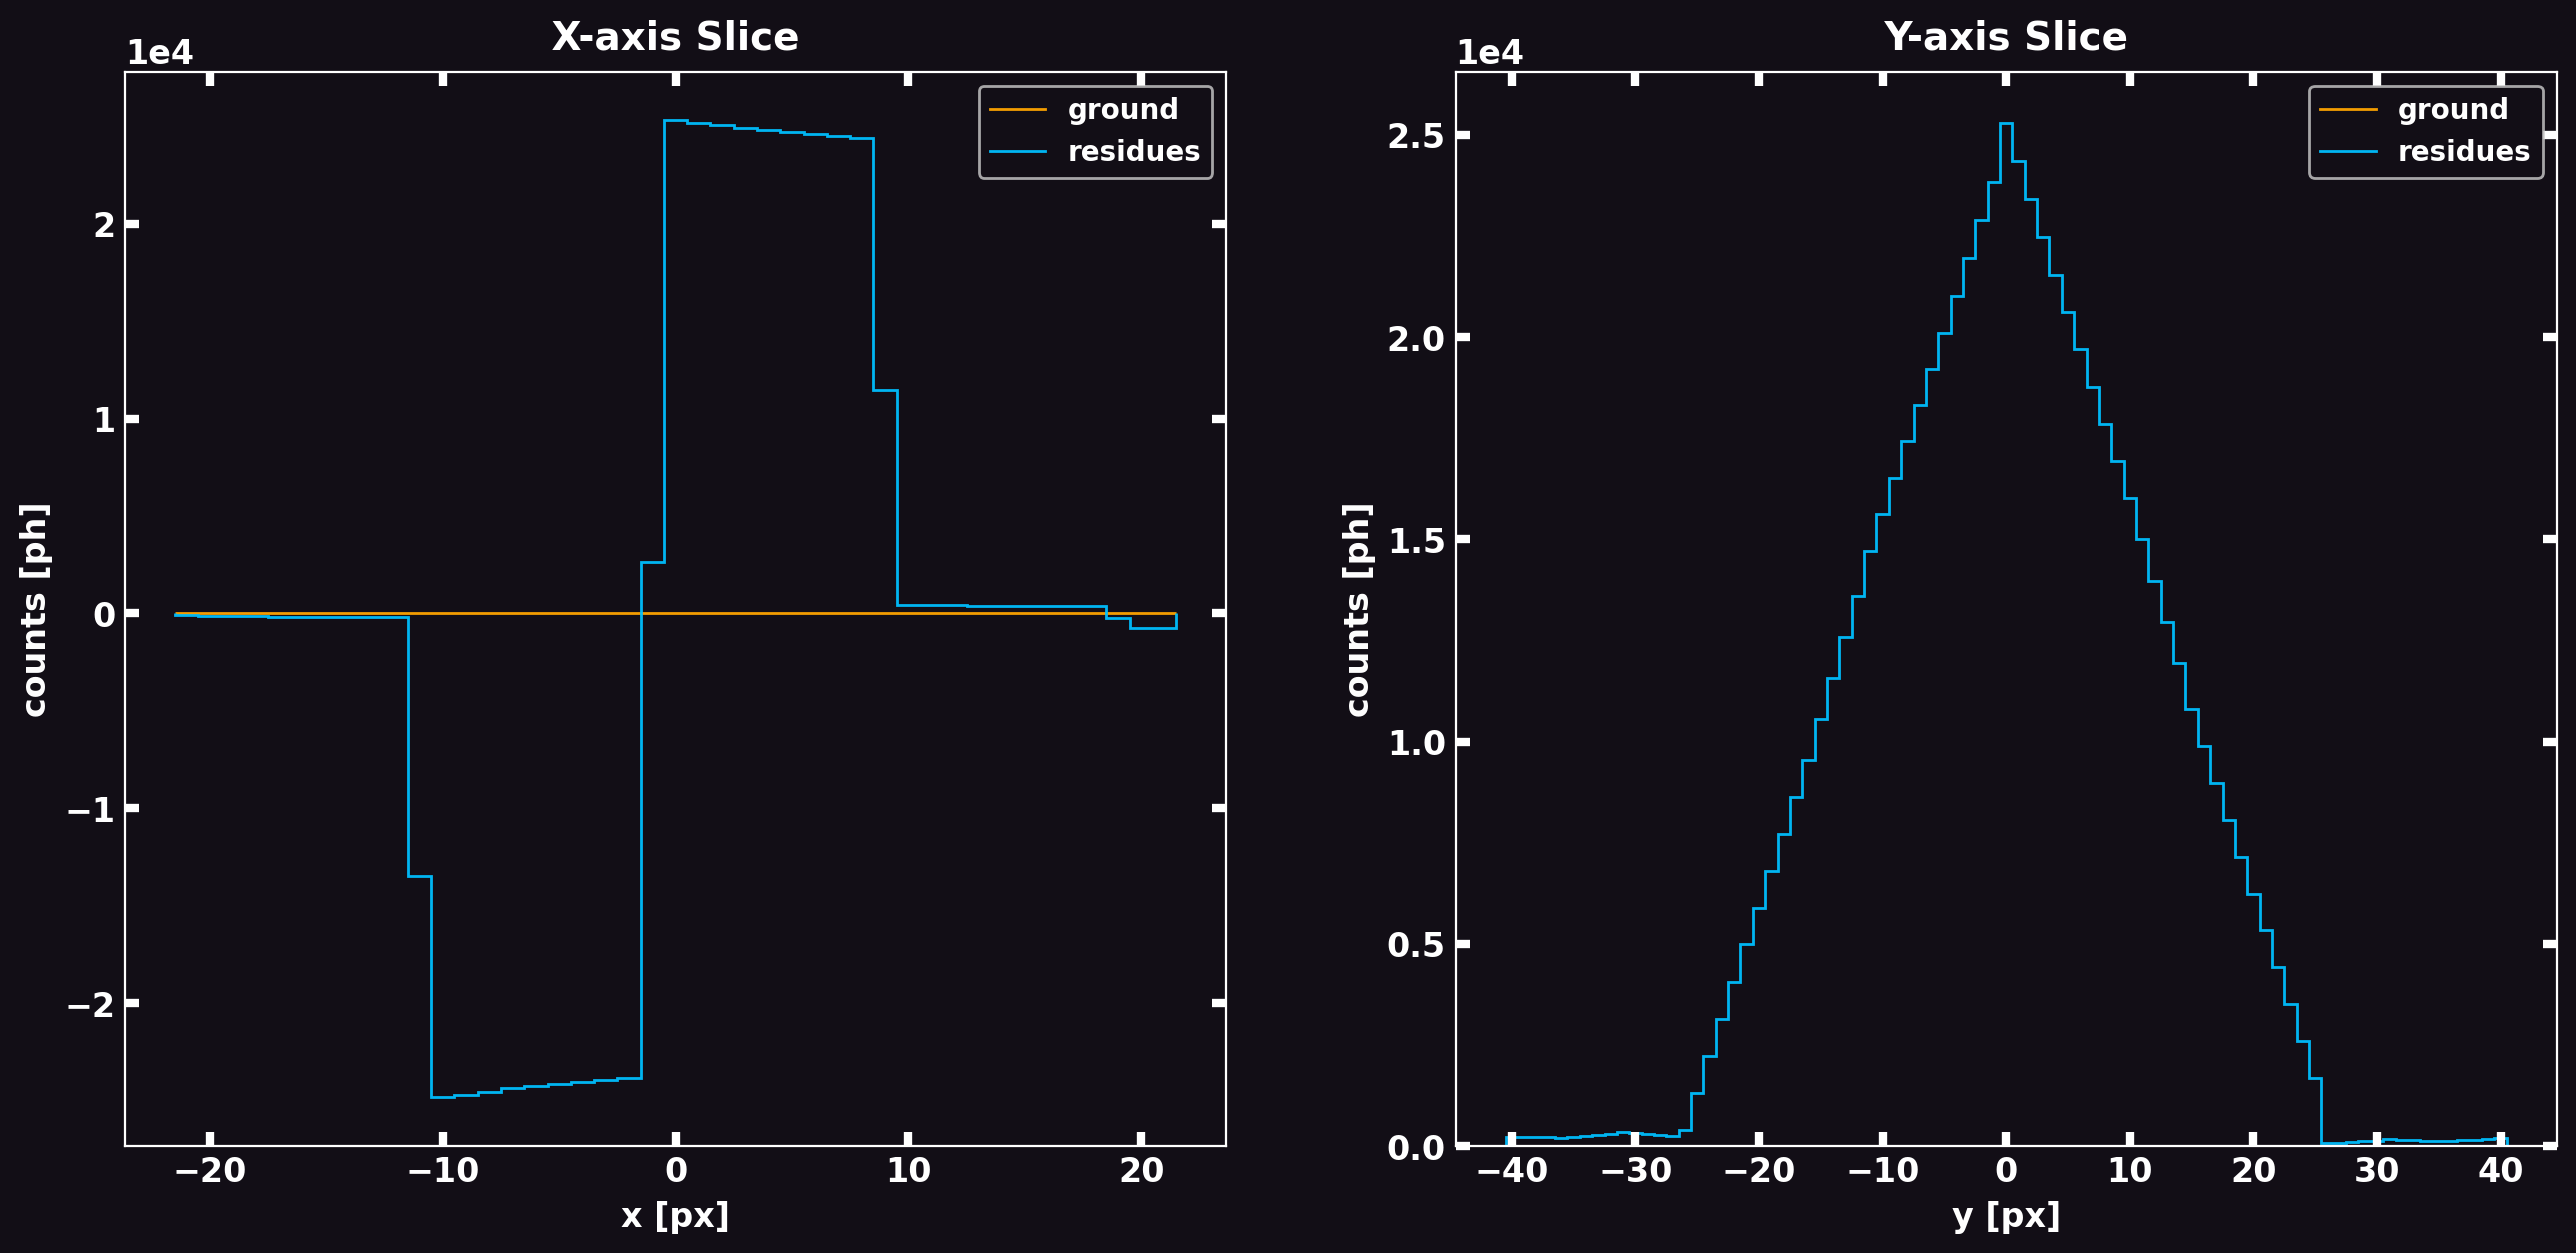

In [8]:
# ds.slices_plot(
#     sky=(skymap_thin, skymap),
#     pos=SRC_DATA['pos'],
#     crp=SRC_DATA['crp'],
#     labels=('thin', 'vignetted'),
#     color=SRC_DATA['colors'],
# )
ds.slices_plot(
    sky=(template_thin, template),
    pos=argmax(template_thin),
    crp=SRC_DATA['crp'],
    labels=('thin', 'vignetted'),
    color=SRC_DATA['colors'],
)
ds.slices_plot(
    sky=(np.zeros_like(template_thin), template_thin - template),
    pos=argmax(template_thin),
    crp=SRC_DATA['crp'],
    labels=('ground', 'residues'),
    color=SRC_DATA['colors'],
)